# ============================================
# MACHINE LEARNING TASK 1: SALES FORECASTING
# Future Interns - ML Internship Task
# ============================================

"""
🎯 PROBLEM STATEMENT:
We will predict monthly sales for the next 3–6 months to help the business 
manage inventory and staffing. This forecast will enable:
- Better inventory planning (avoid stockouts/overstock)
- Optimal staffing during peak seasons
- Improved cash flow management
- Strategic marketing timing
"""


In [45]:
# STEP 1: IMPORT LIBRARIES & LOAD DATA


# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Machine Learning libraries
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Visualization styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

In [46]:
# Load the dataset

df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')
print(f"\nDataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
print(df.head())


Dataset loaded: 9994 rows, 21 columns

First 5 rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID

In [47]:
# STEP 2: DATA CLEANING

# Create a copy to work with
df_clean = df.copy()

# 1. Convert Order Date to datetime
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
print("\nConverted Order Date to datetime")
df_clean['Order Date']





Converted Order Date to datetime


0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]

In [48]:
# 2. Check for duplicates
duplicates = df_clean.duplicated().sum()
print(f"Duplicates found: {duplicates}")


Duplicates found: 0


In [49]:
# 3. Check missing values
print("\n📊 Missing Values:")
print(df_clean.isnull().sum())


📊 Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [50]:
# 4. Check negative sales (returns)
negative_sales = df_clean[df_clean['Sales'] < 0].shape[0]
print(f"\n✅ Negative sales entries (returns): {negative_sales}")


✅ Negative sales entries (returns): 0


In [51]:
# 5. Check data types
print(df_clean.dtypes)


Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [52]:
# 6. Basic statistics
print("\n📊 Sales Statistics:")
print(df_clean['Sales'].describe())

# 7. Check date range of dataset
start_date = df_clean["Order Date"].min()
end_date = df_clean["Order Date"].max()

print("\nDataset covers from", start_date, "to", end_date)
print("Total duration (in days):", (end_date - start_date).days)


📊 Sales Statistics:
count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

Dataset covers from 2014-01-03 00:00:00 to 2017-12-30 00:00:00
Total duration (in days): 1457


In [53]:
# ============================================
# STEP 3: SIMPLE TIME FEATURES


# Extract only important features
df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter

print("Year, Month and Quarter columns created.")

print("\nPreview:")
print(df_clean[["Order Date", "Year", "Month", "Quarter"]].head())

Year, Month and Quarter columns created.

Preview:
  Order Date  Year  Month  Quarter
0 2016-11-08  2016     11        4
1 2016-11-08  2016     11        4
2 2016-06-12  2016      6        2
3 2015-10-11  2015     10        4
4 2015-10-11  2015     10        4


In [54]:
# ============================================
# STEP 4: CREATE MONTHLY TIME SERIES
# ============================================

print("\nCreating monthly sales data...\n")

# Set date as index
df_clean = df_clean.set_index("Order Date")

# Aggregate sales monthly
monthly_sales = df_clean.resample("M")["Sales"].sum()

print("Monthly aggregation done.")
print("Total months:", len(monthly_sales))
print("Date range:", monthly_sales.index.min(), "to", monthly_sales.index.max())

print("\nFirst 5 months:")
print(monthly_sales.head())

print("\nLast 5 months:")
print(monthly_sales.tail())

# Calculate month-over-month growth
monthly_sales = monthly_sales.to_frame()
monthly_sales["SalesGrowth"] = monthly_sales["Sales"].pct_change() * 100

print("\nAverage monthly sales:", round(monthly_sales["Sales"].mean(), 2))


Creating monthly sales data...

Monthly aggregation done.
Total months: 48
Date range: 2014-01-31 00:00:00 to 2017-12-31 00:00:00

First 5 months:
Order Date
2014-01-31    14236.895
2014-02-28     4519.892
2014-03-31    55691.009
2014-04-30    28295.345
2014-05-31    23648.287
Freq: ME, Name: Sales, dtype: float64

Last 5 months:
Order Date
2017-08-31     63120.8880
2017-09-30     87866.6520
2017-10-31     77776.9232
2017-11-30    118447.8250
2017-12-31     83829.3188
Freq: ME, Name: Sales, dtype: float64

Average monthly sales: 47858.35



Visualizing sales trends...



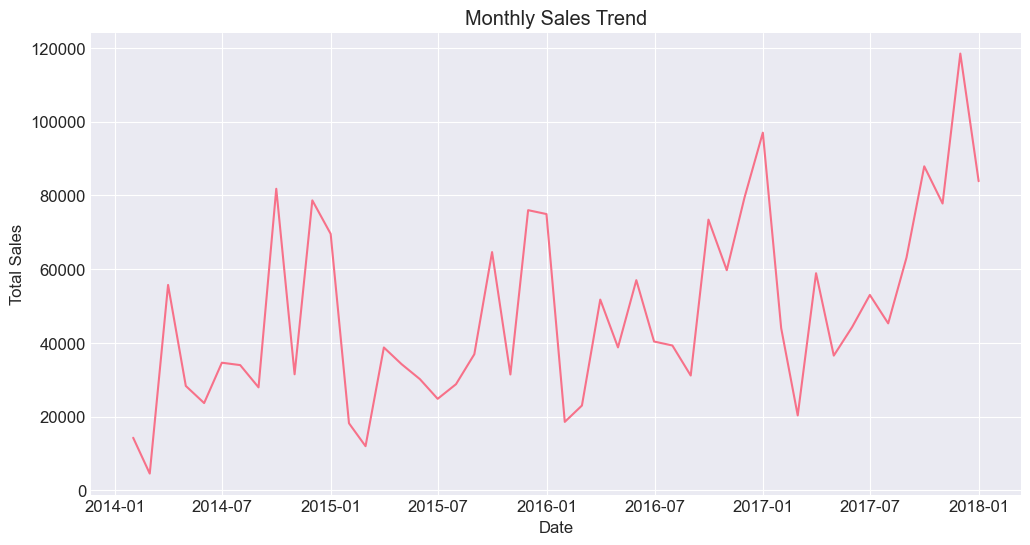

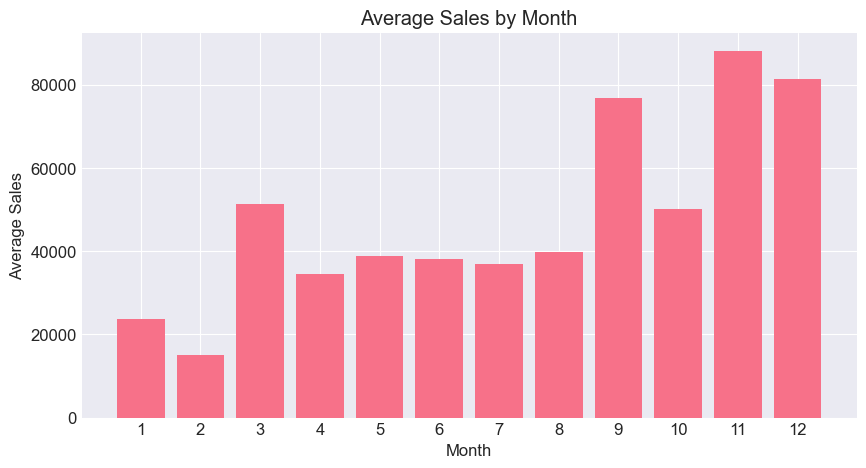

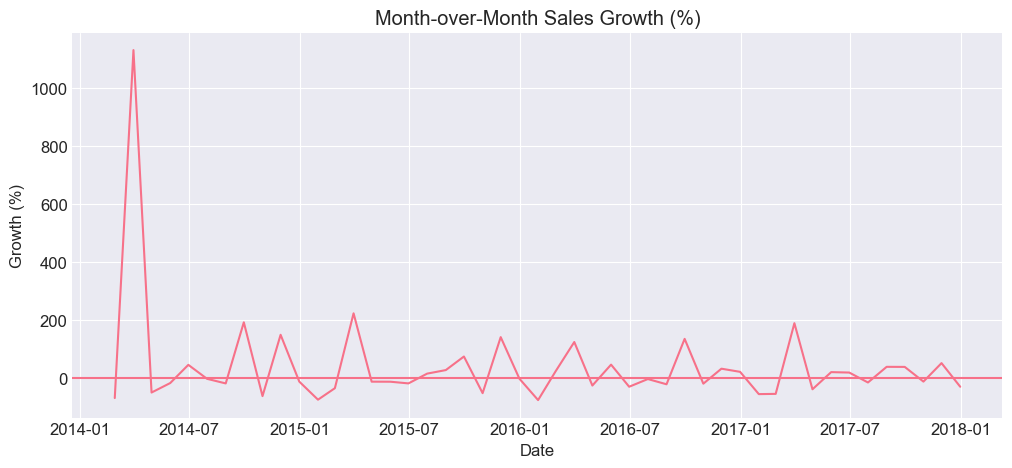


Visualization completed successfully.


In [56]:
# ============================================
# STEP 5: VISUALIZE SALES TRENDS
# ============================================

print("\nVisualizing sales trends...\n")

import matplotlib.pyplot as plt

# Make sure monthly_sales is a DataFrame
if isinstance(monthly_sales, pd.Series):
    monthly_sales = monthly_sales.to_frame(name="Sales")

# --------------------------------------------
# 1. Monthly Sales Trend
# --------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales["Sales"])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


# --------------------------------------------
# 2. Average Sales by Month (Seasonality)
# --------------------------------------------

# Create temporary copy
temp = monthly_sales.copy()

# Extract month from index
temp["Month"] = temp.index.month

# Calculate average sales per month
avg_by_month = temp.groupby("Month")["Sales"].mean()

plt.figure(figsize=(10, 5))
plt.bar(avg_by_month.index, avg_by_month.values)
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(range(1, 13))
plt.show()


# --------------------------------------------
# 3. Month-over-Month Growth
# --------------------------------------------

# Calculate growth %
monthly_sales["SalesGrowth"] = monthly_sales["Sales"].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales["SalesGrowth"])
plt.axhline(0)
plt.title("Month-over-Month Sales Growth (%)")
plt.xlabel("Date")
plt.ylabel("Growth (%)")
plt.grid(True)
plt.show()

print("\nVisualization completed successfully.")

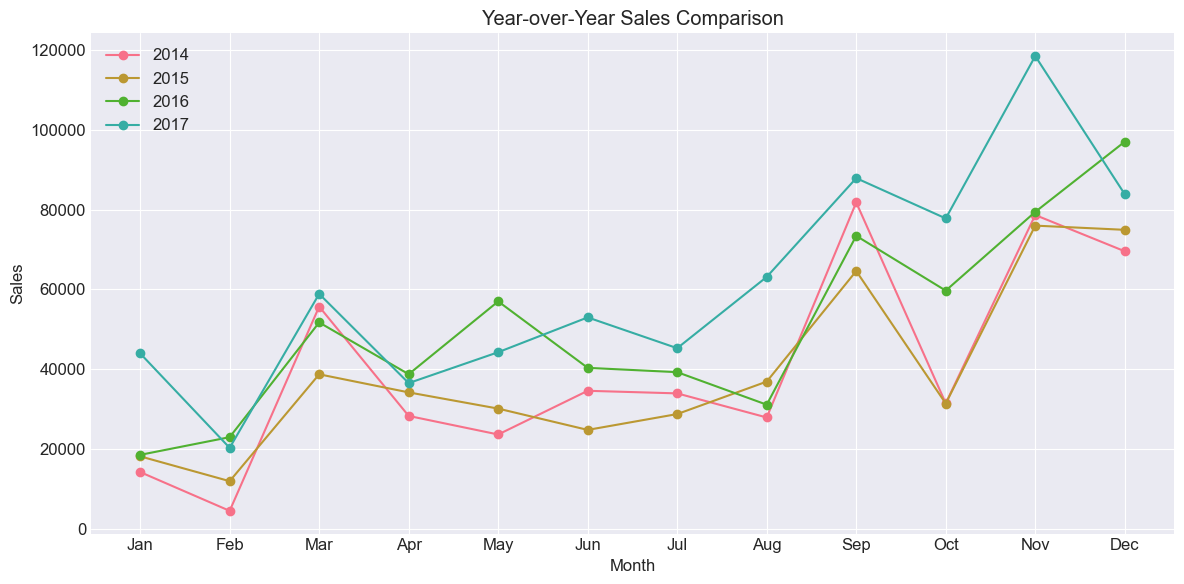

In [ ]:
# ============================================
# Year-over-Year Sales Comparison
# ============================================

# Create a temporary copy
temp = monthly_sales.copy()

# Extract Year and Month from index
temp["Year"] = temp.index.year
temp["Month"] = temp.index.month

plt.figure(figsize=(12, 6))

for year in temp["Year"].unique():
    year_data = temp[temp["Year"] == year]
    plt.plot(year_data["Month"], year_data["Sales"], 
             marker="o", label=str(year))

plt.title("Year-over-Year Sales Comparison")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.xticks(range(1, 13),
           ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
            "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])

plt.tight_layout()
plt.show()



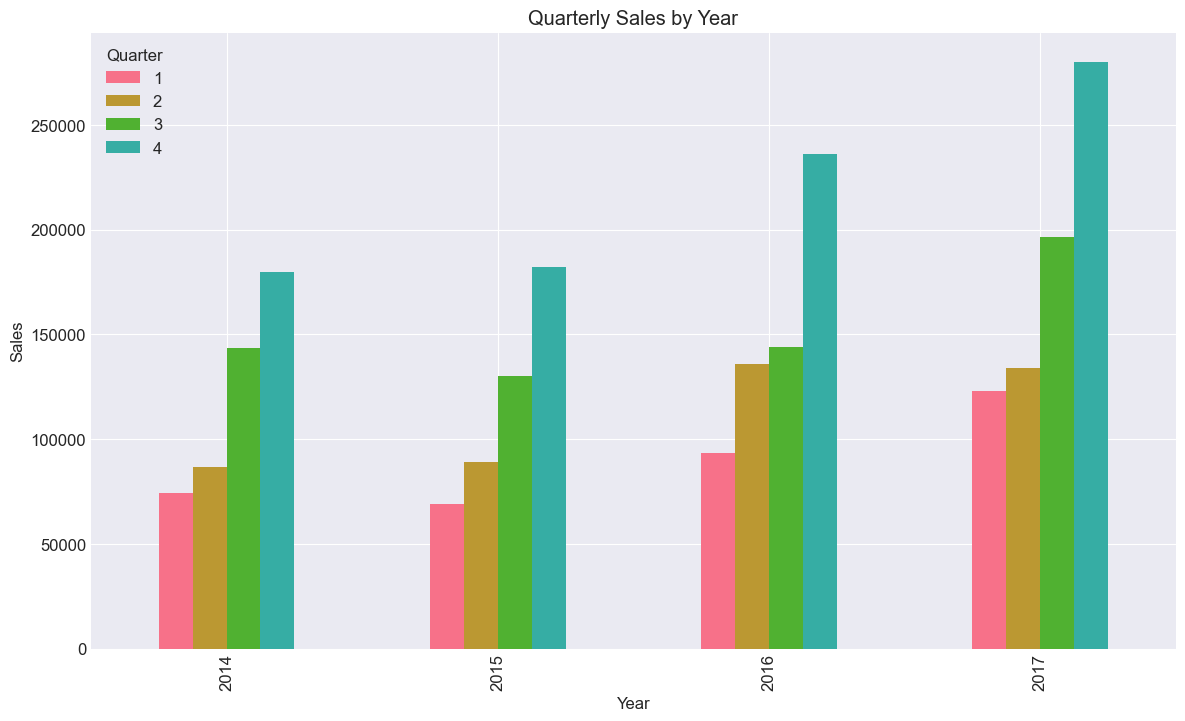

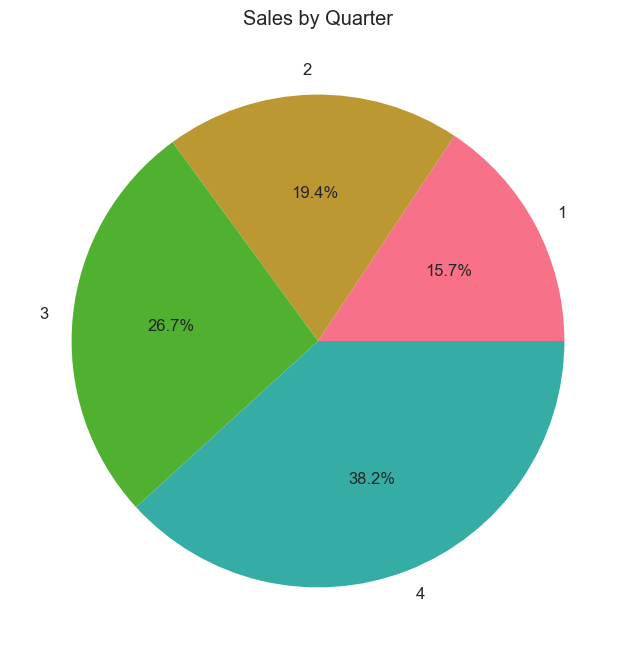

In [ ]:
# ============================================
# Quarterly Sales Performance
# ============================================

# Add Year and Quarter directly
monthly_sales["Year"] = monthly_sales.index.year
monthly_sales["Quarter"] = monthly_sales.index.quarter

# Group and plot bar chart
monthly_sales.groupby(["Year", "Quarter"])["Sales"].sum().unstack().plot(kind="bar")

plt.title("Quarterly Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

# Quarterly Distribution (Pie Chart)

monthly_sales.groupby("Quarter")["Sales"].sum().plot(kind="pie", autopct="%1.1f%%")

plt.title("Sales by Quarter")
plt.ylabel("")
plt.show()

In [93]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Assume monthly_sales is your monthly sales DataFrame, sorted by date
monthly_sales = monthly_sales.sort_index()

# Reset index to make 'Order Date' a column
model_df = monthly_sales.reset_index()

# -------------------------------
# Step 1: Create time features
# -------------------------------
model_df["month"] = model_df["Order Date"].dt.month
model_df["quarter"] = model_df["Order Date"].dt.quarter
model_df["year"] = model_df["Order Date"].dt.year

# -------------------------------
# Step 2: Create lag features
# -------------------------------
for i in range(1, 7):
    model_df[f"lag_{i}"] = model_df["Sales"].shift(i)

# -------------------------------
# Step 3: Create rolling averages (shifted to avoid leakage)
# -------------------------------
model_df["roll_mean_3"] = model_df["Sales"].shift(1).rolling(window=3).mean()
model_df["roll_mean_6"] = model_df["Sales"].shift(1).rolling(window=6).mean()

# -------------------------------
# Step 4: Drop rows with missing values
# -------------------------------
model_df = model_df.dropna()


In [94]:
# -------------------------------
# Step 5: Split into train/test AFTER features
# -------------------------------
train_size = int(len(model_df) * 0.8)
train = model_df.head(train_size)
test = model_df.tail(len(model_df) - train_size)

X_train = train.drop(columns=["Sales", "Order Date"])
y_train = train["Sales"]
X_test = test.drop(columns=["Sales", "Order Date"])
y_test = test["Sales"]

In [95]:
# -------------------------------
# Step 6: Train models
# -------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [96]:
# -------------------------------
# Step 7: Predict and evaluate
# -------------------------------
lr_pred = lr_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Linear Regression MAE: 8467.090872678498
Random Forest MAE: 12117.12021155557
Linear Regression RMSE: 11492.252398643526
Random Forest RMSE: 14921.181198157214


In [97]:
future_predictions = pd.DataFrame({
    "Order Date": test["Order Date"],
    "Actual Sales": y_test,
    "LR Prediction": lr_pred,
    "RF Prediction": rf_pred
})
future_predictions.to_csv("sales_forecast.csv", index=False)

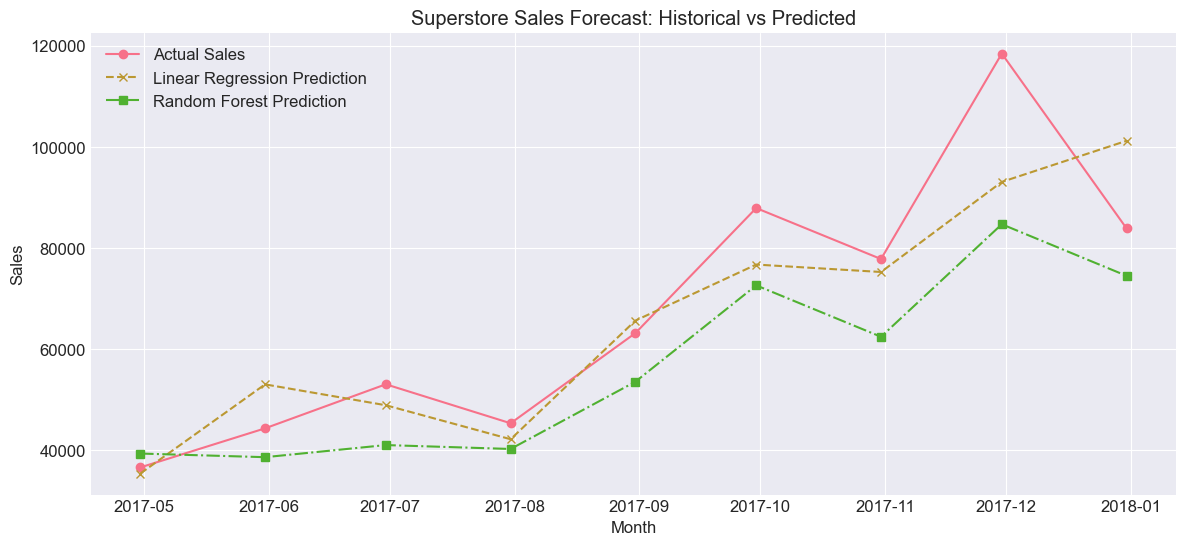

In [98]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(test["Order Date"], y_test, label="Actual Sales", marker='o')
plt.plot(test["Order Date"], lr_pred, label="Linear Regression Prediction", linestyle='--', marker='x')
plt.plot(test["Order Date"], rf_pred, label="Random Forest Prediction", linestyle='-.', marker='s')
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Superstore Sales Forecast: Historical vs Predicted")
plt.legend()
plt.grid(True)
plt.show()